# 📧 Email Spam Classification — NLP Pipeline Logistic Regression

**Dataset:** SpamAssassin (5,796 emails — 3,900 ham / 1,896 spam)  
**Model:** Logistic Regression + TF-IDF (1,2)-grams + Hand-Crafted Features

### Key Design Decisions
| Concern | Solution |
|---|---|
| **Data Leakage** | Train/test split BEFORE feature fitting; `Pipeline` enforces fit-on-train-only |
| **Overfitting** | StratifiedKFold CV, L2 regularisation  |
| **Class Imbalance** | `class_weight='balanced'` + stratified splits |

### Table of Contents
1. [Imports & Setup](#1)
2. [Load & Explore Data](#2)
3. [Text Preprocessing](#3)
4. [Hand-Crafted Feature Engineering](#4)
5. [Train / Test Split](#5)
6. [Combined Pipeline](#6)
7. [Cross-Validation](#7)
8. [Hyperparameter Tuning](#8)
9. [Learning Curves](#9)
10. [Final Evaluation](#10)
11. [Feature Importance](#11)
12. [Summary](#12)


---
## 1. Imports & Setup <a id='1'></a>

In [13]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from email import message_from_string
from scipy.sparse import hstack, csr_matrix
import mlflow


import sys
sys.path.append("/Users/kaushikchariya/Deep-Shield-Mail")

import mlflow.sklearn

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline                import Pipeline
from sklearn.base                    import BaseEstimator, TransformerMixin
from sklearn.preprocessing           import StandardScaler
from sklearn.linear_model            import LogisticRegression
from sklearn.model_selection         import (
    train_test_split, StratifiedKFold,
    cross_validate, learning_curve, GridSearchCV,
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay, roc_curve, auc,
)
from scipy.sparse import hstack, csr_matrix

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
SEED = 42
print('Imports ready ✅')


Imports ready ✅


---
## 2. Load & Explore Data <a id='2'></a>

In [14]:
df = pd.read_csv('../data/spam_assassin.csv')

print('Shape   :', df.shape)
print('Columns :', df.columns.tolist())
print('Nulls:\n', df.isnull().sum())
df.head(3)


Shape   : (5796, 2)
Columns : ['text', 'target']
Nulls:
 text      0
target    0
dtype: int64


,text,target
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,0
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,1
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,1


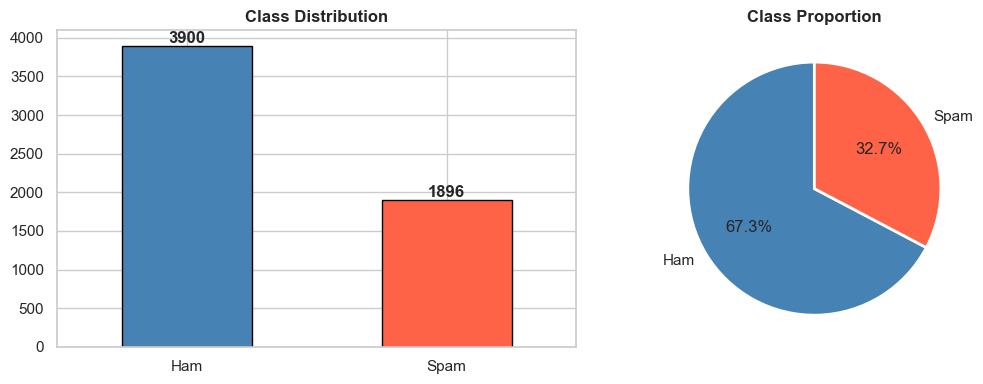

⚠️  Imbalanced — using stratified splits + class_weight="balanced"


In [15]:
# Label distribution
label_map = {0: 'Ham', 1: 'Spam'}
df['label'] = df['target'].map(label_map)
counts = df['label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion', fontweight='bold')

plt.tight_layout()
plt.show()
print('⚠️  Imbalanced — using stratified splits + class_weight="balanced"')


      char_count                                                           \
           count    mean     std    min     25%     50%     75%       max   
label                                                                       
Ham       3900.0  3483.1  3134.1  362.0  2435.2  3196.5  4049.2   92469.0   
Spam      1896.0  5667.1  9068.5  736.0  2391.8  3824.0  6304.0  232305.0   

      word_count                                                    
           count   mean    std   min    25%    50%    75%      max  
label                                                               
Ham       3900.0  405.7  484.9  45.0  262.0  347.0  454.0  15164.0  
Spam      1896.0  545.6  612.2  73.0  250.0  386.0  617.2  11857.0  


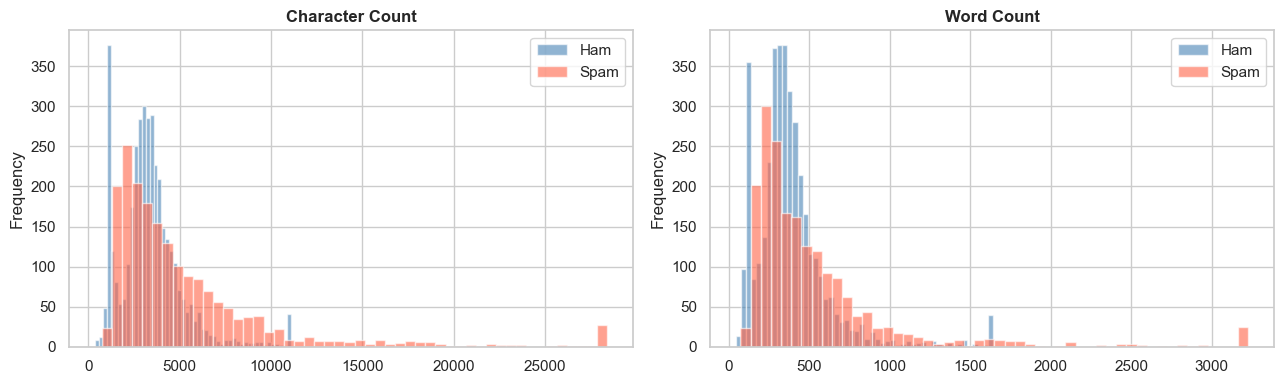

In [16]:
# Email length by class
df['char_count'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

print(df.groupby('label')[['char_count', 'word_count']].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, title in zip(axes,
                           ['char_count', 'word_count'],
                           ['Character Count', 'Word Count']):
    for lbl, color in [('Ham', 'steelblue'), ('Spam', 'tomato')]:
        subset = df[df['label'] == lbl][col]
        subset.clip(upper=subset.quantile(0.99)).plot(
            kind='hist', bins=50, ax=ax, alpha=0.6,
            color=color, label=lbl, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.show()

df.drop(columns=['char_count', 'word_count', 'label'], inplace=True)


---
## 3. Text Preprocessing <a id='3'></a>

> Purely rule-based — no statistics learned. Safe to apply before the split.


In [17]:
def preprocess_email(text: str) -> str:
    if not isinstance(text, str):
        return ''
    text = text.lower()
    # Remove email headers
    text = re.sub(r'^(from|subject|to|cc|bcc|received|content-type|mime-version|'
                  r'message-id|return-path|delivered-to|x-[a-z-]+):.*$',
                  '', text, flags=re.MULTILINE | re.IGNORECASE)
    text = re.sub(r'https?://\S+|www\.\S+', ' url ', text)   # URLs
    text = re.sub(r'[\w.+-]+@[\w-]+\.[\w.-]+', ' email ', text) # emails
    text = re.sub(r'\$\s*\d+[\d,.]*', ' money ', text)          # currency
    text = re.sub(r'\b(\+?\d[\s.-]?){7,15}\b', ' phone ', text) # phones
    text = re.sub(r'<[^>]+>', ' ', text)                          # HTML tags
    text = re.sub(r'[^a-z\s]', ' ', text)                        # non-alpha
    text = re.sub(r'\s+', ' ', text).strip()
    return text


df['clean_text'] = df['text'].apply(preprocess_email)

print('Sample — Original:')
print(df['text'].iloc[1][:250])
print('\nSample — Cleaned:')
print(df['clean_text'].iloc[1][:250])


Sample — Original:
From gort44@excite.com Mon Jun 24 17:54:21 2002 Return-Path: gort44@excite.com Delivery-Date: Tue Jun 4 05:31:16 2002 Received: from mandark.labs.netnoteinc.com ([213.105.180.140]) by dogma.slashnull.org (8.11.6/8.11.6) with ESMTP id g544VFO20182 for

Sample — Cleaned:
from email mon jun return path email delivery date tue jun received from mandark labs netnoteinc com phone by dogma slashnull org with esmtp id g vfo for tue jun received from wi poli poli cl phone by mandark labs netnoteinc com with smtp id g vc tue


---
## 4. Hand-Crafted Feature Engineering <a id='4'></a>

> Stateless features — no corpus statistics learned. Safe before the split.

| Feature | Spam signal |
|---|---|
| `caps_ratio` | ALL CAPS shouting |
| `exclamation_count` | Urgency punctuation `!!!` |
| `url_count` | Phishing / affiliate links |
| `dollar_count` | Money promises |
| `html_flag` | Bulk HTML emails |
| `word_count` | Verbose spam |
| `avg_word_length` | Gibberish padding |
| `digit_ratio` | Phone numbers, tracking codes |
| `unique_word_ratio` | Low ratio → repetitive spam |


In [18]:
def extract_features(series: pd.Series) -> pd.DataFrame:
    raw = series.fillna('')
    words = raw.str.split()
    return pd.DataFrame({
        'caps_ratio'       : raw.apply(lambda t: sum(c.isupper() for c in t) / max(len(t), 1)),
        'exclamation_count': raw.str.count(r'!'),
        'url_count'        : raw.str.count(r'https?://|www\.'),
        'dollar_count'     : raw.str.count(r'\$'),
        'html_flag'        : raw.str.contains(r'<html|<body|<table|<td|<font',
                                              case=False, regex=True).astype(int),
        'word_count'       : words.str.len().fillna(0),
        'avg_word_length'  : words.apply(
                                lambda ws: np.mean([len(w) for w in ws])
                                if isinstance(ws, list) and ws else 0),
        'digit_ratio'      : raw.apply(lambda t: sum(c.isdigit() for c in t) / max(len(t), 1)),
        'unique_word_ratio': words.apply(
                                lambda ws: len(set(ws)) / max(len(ws), 1)
                                if isinstance(ws, list) and ws else 0),
    }, index=series.index).astype(float)


feat_df = extract_features(df['text'])
df = pd.concat([df, feat_df], axis=1)
HAND_FEAT_COLS = feat_df.columns.tolist()

print('Hand-crafted features:', HAND_FEAT_COLS)
print()
print(feat_df.describe().round(3).to_string())


Hand-crafted features: ['caps_ratio', 'exclamation_count', 'url_count', 'dollar_count', 'html_flag', 'word_count', 'avg_word_length', 'digit_ratio', 'unique_word_ratio']

       caps_ratio  exclamation_count  url_count  dollar_count  html_flag  word_count  avg_word_length  digit_ratio  unique_word_ratio
count    5796.000           5796.000   5796.000      5796.000   5796.000    5796.000         5796.000     5796.000           5796.000
mean        0.075              2.578      6.277         1.751      0.180     451.448            8.513        0.104              0.636
std         0.051              6.854     19.346         8.594      0.384     533.936            3.429        0.032              0.078
min         0.019              0.000      0.000         0.000      0.000      45.000            4.095        0.005              0.150
25%         0.054              0.000      2.000         0.000      0.000     258.750            7.121        0.085              0.598
50%         0.063        

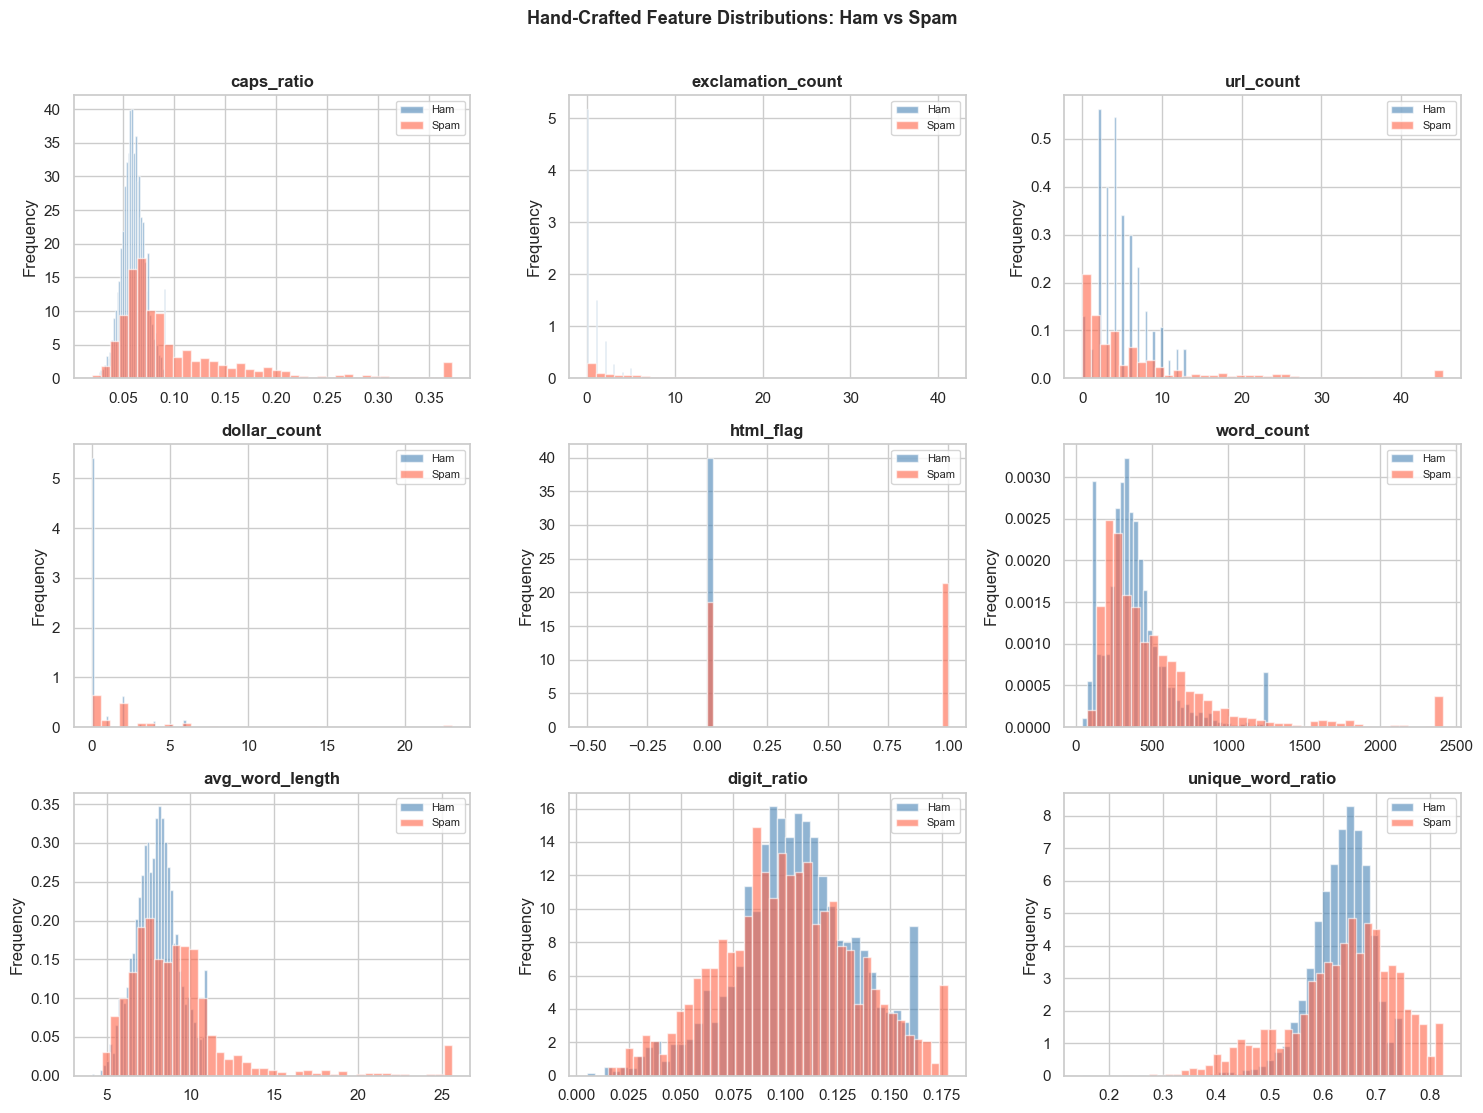

Feature distributions plotted ✅


In [19]:
# Distribution: Ham vs Spam for each feature
label_map = {0: 'Ham', 1: 'Spam'}
df['_label'] = df['target'].map(label_map)

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for ax, col in zip(axes, HAND_FEAT_COLS):
    for lbl, color in [('Ham', 'steelblue'), ('Spam', 'tomato')]:
        subset = df[df['_label'] == lbl][col]
        subset.clip(upper=subset.quantile(0.98)).plot(
            kind='hist', bins=40, ax=ax, alpha=0.6,
            color=color, label=lbl, edgecolor='white', density=True)
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Hand-Crafted Feature Distributions: Ham vs Spam',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

df.drop(columns=['_label'], inplace=True)
print('Feature distributions plotted ✅')


---
## 5. Train / Test Split <a id='5'></a>

> ⚠️ TF-IDF is fitted **only on training data** inside the pipeline. Test set is locked until Section 10.


In [20]:
X_text  = df['clean_text']
X_feats = df[HAND_FEAT_COLS]
y       = df['target']

(X_train_text, X_test_text,
 X_train_feats, X_test_feats,
 y_train, y_test) = train_test_split(
    X_text, X_feats, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)

print(f'Train : {X_train_text.shape[0]} samples')
print(f'Test  : {X_test_text.shape[0]} samples')
print()
print('Train class split:')
print(y_train.value_counts(normalize=True).rename({0:'Ham',1:'Spam'}).map('{:.1%}'.format))
print('\nTest class split:')
print(y_test.value_counts(normalize=True).rename({0:'Ham',1:'Spam'}).map('{:.1%}'.format))
print('\n✅ Test set locked — not touched until Section 10')


Train : 4636 samples
Test  : 1160 samples

Train class split:
target
Ham     67.3%
Spam    32.7%
Name: proportion, dtype: object

Test class split:
target
Ham     67.3%
Spam    32.7%
Name: proportion, dtype: object

✅ Test set locked — not touched until Section 10


In [21]:
import dagshub

mlflow.set_tracking_uri('https://dagshub.com/kaushik-chariya/Deep-Shield-Mail.mlflow')
dagshub.init(repo_owner='kaushik-chariya', repo_name='Deep-Shield-Mail', mlflow=True)


mlflow.set_experiment("LogisticRegression-Spam-Detection-HyperParamater")

Initialized MLflow to track repo "kaushik-chariya/Deep-Shield-Mail"

Repository kaushik-chariya/Deep-Shield-Mail initialized!

<Experiment: artifact_location='mlflow-artifacts:/4758813aa1244e2e96eda0fb4659a37e', creation_time=1779059956231, experiment_id='11', last_update_time=1779059956231, lifecycle_stage='active', name='LogisticRegression-Spam-Detection-HyperParamater', tags={}>

---
## 6. Combined Pipeline <a id='6'></a>

Two feature streams merged with `hstack`:
- **TF-IDF** (sparse, 30 k ngrams) — fitted on training data only
- **Hand-crafted** (dense, 9 features) — `StandardScaler` fitted on training data only


In [22]:
import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature
from sklearn.metrics import (accuracy_score, f1_score,
                             precision_score, recall_score,
                             roc_auc_score, classification_report,
                             confusion_matrix)


# ─── Custom classes ────────────────────────────────────────────────
class TextSelector(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X): return X['text']

class DenseSelector(BaseEstimator, TransformerMixin):
    def __init__(self, feat_cols): self.feat_cols = feat_cols
    def fit(self, X, y=None): return self
    def transform(self, X): return X[self.feat_cols].values

TFIDF_PARAMS = dict(
    analyzer     = 'word',
    ngram_range  = (1, 2),
    stop_words   = 'english',
    sublinear_tf = True,
    max_features = 30_000,
    min_df       = 3,
    max_df       = 0.90,
    strip_accents= 'unicode',
)

class CombinedFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, feat_cols, tfidf_pipe, dense_pipe):
        self.feat_cols  = feat_cols
        self.tfidf_pipe = tfidf_pipe
        self.dense_pipe = dense_pipe

    def fit(self, X, y=None):
        self.tfidf_pipe.fit(X, y)
        self.dense_pipe.fit(X, y)
        return self

    def transform(self, X):
        sparse = self.tfidf_pipe.transform(X)
        dense  = csr_matrix(self.dense_pipe.transform(X))
        return hstack([sparse, dense])

def make_pipeline(C=1.0):
    tfidf_branch = Pipeline([
        ('sel',   TextSelector()),
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
    ])
    dense_branch = Pipeline([
        ('sel',    DenseSelector(HAND_FEAT_COLS)),
        ('scaler', StandardScaler()),
    ])
    return Pipeline([
        ('features', CombinedFeatures(
            feat_cols  = HAND_FEAT_COLS,
            tfidf_pipe = tfidf_branch,
            dense_pipe = dense_branch,
        )),
        ('clf', LogisticRegression(
            C            = C,
            max_iter     = 1000,
            class_weight = 'balanced',
            solver       = 'lbfgs',
            random_state = SEED,
        )),
    ])

# ─── Combined DataFrame ────────────────────────────────────────────
X_train_combined = (X_train_text.reset_index(drop=True)
                                 .rename('text').to_frame()
                                 .join(X_train_feats.reset_index(drop=True)))
X_test_combined  = (X_test_text.reset_index(drop=True)
                                .rename('text').to_frame()
                                .join(X_test_feats.reset_index(drop=True)))

print(f'Pipeline ready ✅  |  X_train shape: {X_train_combined.shape}')

# ─── MLflow Run ────────────────────────────────────────────────────
with mlflow.start_run(run_name="LogisticRegression-CombinedFeatures"):

    # ── Tags ────────────────────────────────────────────────────────
    mlflow.set_tags({
        'model'   : 'LogisticRegression',
        'features': 'tfidf + hand-crafted',
        'stage'   : 'cv + final-eval',
        'dataset' : 'SpamAssassin',
    })

    # ── Params log ──────────────────────────────────────────────────
    mlflow.log_params({
        'C'                 : 1.0,
        'max_iter'          : 1000,
        'class_weight'      : 'balanced',
        'solver'            : 'lbfgs',
        'random_state'      : SEED,
        'tfidf_ngram_range' : str(TFIDF_PARAMS['ngram_range']),
        'tfidf_max_features': TFIDF_PARAMS['max_features'],
        'tfidf_min_df'      : TFIDF_PARAMS['min_df'],
        'tfidf_max_df'      : TFIDF_PARAMS['max_df'],
        'tfidf_sublinear_tf': TFIDF_PARAMS['sublinear_tf'],
        'hand_feat_count'   : len(HAND_FEAT_COLS),
        'cv_folds'          : 5,
        'train_size'        : len(y_train),
        'test_size'         : len(y_test),
    })

    # ── 5-Fold CV ────────────────────────────────────────────────────
    print('\nRunning 5-Fold CV...')
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

    scores = cross_validate(
        make_pipeline(),
        X_train_combined, y_train,
        cv=skf,
        scoring=['accuracy', 'f1', 'precision', 'recall', 'roc_auc'],
        return_train_score=True,
        n_jobs=1,
    )

    train_f1 = scores['train_f1'].mean()
    val_f1   = scores['test_f1'].mean()
    gap      = train_f1 - val_f1

    # ── CV metrics log ───────────────────────────────────────────────
    mlflow.log_metrics({
        'cv_accuracy'    : scores['test_accuracy'].mean(),
        'cv_accuracy_std': scores['test_accuracy'].std(),
        'cv_f1'          : val_f1,
        'cv_f1_std'      : scores['test_f1'].std(),
        'cv_precision'   : scores['test_precision'].mean(),
        'cv_recall'      : scores['test_recall'].mean(),
        'cv_auc_roc'     : scores['test_roc_auc'].mean(),
        'cv_auc_roc_std' : scores['test_roc_auc'].std(),
        'cv_train_f1'    : train_f1,
        'cv_overfit_gap' : gap,
    })

    print('Logistic Regression — 5-Fold CV Results')
    print('=' * 45)
    print(f'  Accuracy  : {scores["test_accuracy"].mean():.4f} ± {scores["test_accuracy"].std():.4f}')
    print(f'  F1        : {val_f1:.4f} ± {scores["test_f1"].std():.4f}')
    print(f'  Precision : {scores["test_precision"].mean():.4f}')
    print(f'  Recall    : {scores["test_recall"].mean():.4f}')
    print(f'  AUC-ROC   : {scores["test_roc_auc"].mean():.4f}')
    print(f'  Train F1  : {train_f1:.4f}')
    print(f'  Overfit   : {gap:.4f}  {"⚠️ HIGH" if gap > 0.05 else "✅ OK"}')

    # ── Final model — full train set pe fit ──────────────────────────
    print('\nFitting final model on full training set...')
    final_pipeline = make_pipeline()
    final_pipeline.fit(X_train_combined, y_train)

    y_pred      = final_pipeline.predict(X_test_combined)
    y_pred_prob = final_pipeline.predict_proba(X_test_combined)[:, 1]

    # ── Test metrics log ─────────────────────────────────────────────
    test_metrics = {
        'test_accuracy'  : accuracy_score(y_test, y_pred),
        'test_f1'        : f1_score(y_test, y_pred),
        'test_precision' : precision_score(y_test, y_pred),
        'test_recall'    : recall_score(y_test, y_pred),
        'test_auc_roc'   : roc_auc_score(y_test, y_pred_prob),
    }
    mlflow.log_metrics(test_metrics)

    # ── Confusion matrix log ─────────────────────────────────────────
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    mlflow.log_metrics({'tn': int(tn), 'fp': int(fp),
                        'fn': int(fn), 'tp': int(tp)})

    # ── Classification report artifact ───────────────────────────────
    report = classification_report(y_test, y_pred,
                                   target_names=['Ham', 'Spam'])
    with open("classification_report.txt", "w") as f:
        f.write(report)
    mlflow.log_artifact("classification_report.txt")

    # ── Model artifact log ───────────────────────────────────────────
    signature = infer_signature(X_train_combined,
                                final_pipeline.predict(X_train_combined))
    mlflow.sklearn.log_model(
        final_pipeline,
        artifact_path="logreg_combined",
        signature=signature,
        registered_model_name="spam_logistic_regression_combined",
    )

    print('\n✅ Final model trained on full training set.')
    print('=' * 45)
    print(f'  Test Accuracy  : {test_metrics["test_accuracy"]:.4f}')
    print(f'  Test F1        : {test_metrics["test_f1"]:.4f}')
    print(f'  Test Precision : {test_metrics["test_precision"]:.4f}')
    print(f'  Test Recall    : {test_metrics["test_recall"]:.4f}')
    print(f'  Test AUC-ROC   : {test_metrics["test_auc_roc"]:.4f}')
    print(f'  TN:{tn}  FP:{fp}  FN:{fn}  TP:{tp}')
    print('✅ Run logged to MLflow')

print('\nUI dekhne ke liye:')
print('  mlflow ui --port 5000')

Pipeline ready ✅  |  X_train shape: (4636, 10)

Running 5-Fold CV...
Logistic Regression — 5-Fold CV Results
  Accuracy  : 0.9752 ± 0.0072
  F1        : 0.9620 ± 0.0109
  Precision : 0.9663
  Recall    : 0.9578
  AUC-ROC   : 0.9948
  Train F1  : 0.9733
  Overfit   : 0.0113  ✅ OK

Fitting final model on full training set...


Successfully registered model 'spam_logistic_regression_combined'.
2026/05/18 05:44:35 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: spam_logistic_regression_combined, version 1
Created version '1' of model 'spam_logistic_regression_combined'.



✅ Final model trained on full training set.
  Test Accuracy  : 0.9707
  Test F1        : 0.9545
  Test Precision : 0.9675
  Test Recall    : 0.9420
  Test AUC-ROC   : 0.9940
  TN:769  FP:12  FN:22  TP:357
✅ Run logged to MLflow

UI dekhne ke liye:
  mlflow ui --port 5000


---
## 7. Cross-Validation <a id='7'></a>

5-Fold Stratified CV on training data only.

In [23]:
import mlflow
import mlflow.sklearn


with mlflow.start_run(run_name="LogisticRegression-CombinedFeatures-CV"):

    # ── Tags ────────────────────────────────────────────────────────
    mlflow.set_tags({
        'model'   : 'LogisticRegression',
        'features': 'tfidf + hand-crafted',
        'stage'   : 'cv-only',
        'dataset' : 'SpamAssassin',
    })

    # ── Params log ──────────────────────────────────────────────────
    mlflow.log_params({
        'C'                 : 1.0,
        'max_iter'          : 1000,
        'class_weight'      : 'balanced',
        'solver'            : 'lbfgs',
        'tfidf_ngram_range' : str(TFIDF_PARAMS['ngram_range']),
        'tfidf_max_features': TFIDF_PARAMS['max_features'],
        'tfidf_min_df'      : TFIDF_PARAMS['min_df'],
        'tfidf_sublinear_tf': TFIDF_PARAMS['sublinear_tf'],
        'hand_feat_count'   : len(HAND_FEAT_COLS),
        'cv_folds'          : 5,
        'train_size'        : len(y_train),
    })

    # ── 5-Fold CV ────────────────────────────────────────────────────
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

    scores = cross_validate(
        make_pipeline(),
        X_train_combined, y_train,
        cv=skf,
        scoring=['accuracy', 'f1', 'precision', 'recall', 'roc_auc'],
        return_train_score=True,
        n_jobs=1,
    )

    train_f1 = scores['train_f1'].mean()
    val_f1   = scores['test_f1'].mean()
    gap      = train_f1 - val_f1

    # ── CV metrics log ───────────────────────────────────────────────
    mlflow.log_metrics({
        'cv_accuracy'    : scores['test_accuracy'].mean(),
        'cv_accuracy_std': scores['test_accuracy'].std(),
        'cv_f1'          : val_f1,
        'cv_f1_std'      : scores['test_f1'].std(),
        'cv_precision'   : scores['test_precision'].mean(),
        'cv_recall'      : scores['test_recall'].mean(),
        'cv_auc_roc'     : scores['test_roc_auc'].mean(),
        'cv_auc_roc_std' : scores['test_roc_auc'].std(),
        'cv_train_f1'    : train_f1,
        'cv_overfit_gap' : gap,
    })

    # ── Final model fit ───────────────────────────────────────────────
    final_pipeline = make_pipeline()
    final_pipeline.fit(X_train_combined, y_train)

    mlflow.sklearn.log_model(
        final_pipeline,
        artifact_path="logreg_combined_cv",
        registered_model_name="spam_logistic_regression_combined",
    )

    # ── Print ─────────────────────────────────────────────────────────
    print('Logistic Regression — 5-Fold CV Results')
    print('=' * 45)
    print(f'  Accuracy  : {scores["test_accuracy"].mean():.4f} ± {scores["test_accuracy"].std():.4f}')
    print(f'  F1        : {val_f1:.4f} ± {scores["test_f1"].std():.4f}')
    print(f'  Precision : {scores["test_precision"].mean():.4f}')
    print(f'  Recall    : {scores["test_recall"].mean():.4f}')
    print(f'  AUC-ROC   : {scores["test_roc_auc"].mean():.4f}')
    print(f'  Train F1  : {train_f1:.4f}')
    print(f'  Overfit   : {gap:.4f}  {"⚠️ HIGH" if gap > 0.05 else "✅ OK"}')
    print('\n✅ Final model trained on full training set.')
    print('✅ CV run logged to MLflow')

print('\nUI dekhne ke liye:')
print('  mlflow ui --port 5000')

Registered model 'spam_logistic_regression_combined' already exists. Creating a new version of this model...
2026/05/18 05:45:08 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: spam_logistic_regression_combined, version 2
Created version '2' of model 'spam_logistic_regression_combined'.


Logistic Regression — 5-Fold CV Results
  Accuracy  : 0.9752 ± 0.0072
  F1        : 0.9620 ± 0.0109
  Precision : 0.9663
  Recall    : 0.9578
  AUC-ROC   : 0.9948
  Train F1  : 0.9733
  Overfit   : 0.0113  ✅ OK

✅ Final model trained on full training set.
✅ CV run logged to MLflow

UI dekhne ke liye:
  mlflow ui --port 5000
